# Linear Regression

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/Users/praptibhandari/Desktop/machine learing/Data/mpg.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


---
## 1. Where we are

> **Flow:** KNN predicted a label. Now we predict a number.

Last class the target was `origin` — one of three labels.
Today the target is `mpg` — a number in a range.

---
## 2. What comes next

> **Flow:** Two families of supervised algorithms.

| Regression | Classification |
|---|---|
| **Linear Regression** ← today | KNN ✓ done |
| Ridge / Lasso | Logistic Regression |
| Decision Tree Regressor | Decision Tree |
| Random Forest Regressor | Random Forest |
| KNN Regressor  | |

KNN appears on both sides. If the target is a label the neighbours vote.
If it is a number the neighbours are averaged.

### Practice 2

**Q1.** Amazon wants to predict how many days a delivery will take.
Regression or classification?

**Q2.** Ola wants to predict which of four ride types a customer will book.
Regression or classification?

<details><summary>Answers</summary>

1. Regression — days is a number in a range.
2. Classification — four labels.
</details>

---
## 3. The idea

> **Flow:** A line that passes as close as possible to the points.

**It is the line from school.** `y = mx + c`, with new names:

```
mpg = coef × weight + intercept
```

**Many lines can be drawn.** Only one fits best.

**Residual = actual − predicted.** The vertical distance from a point to the line.

**The best line has the smallest total of squared residuals.**
Squaring stops +4 and −4 cancelling into 0.

**With many features** the line cannot be drawn any more, but the job is the same:

```
mpg = w1×weight + w2×horsepower + ... + intercept
```

### Practice 3

**Q1.** A model predicts 22 for a car whose actual mileage is 26. What is the residual?

**Q2.** One residual is +4 and another is −4. If we just added them, what would the total be,
and why is that a problem?

<details><summary>Answers</summary>

1. 26 − 22 = 4.
2. Zero. A model that is wrong twice looks perfect. Squaring makes both count as 16.
</details>

---
## 4. Load, clean, split

> **Flow:** Get the data ready. Nothing clever today.

In [5]:
df.head(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320


In [6]:
df = df.drop(columns=['name', 'origin'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print(df.shape, "|", df.isna().sum().sum(), "missing")
df.head()

(398, 7) | 0 missing


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


Two columns dropped:

- `name` — unique for every car, so there is no pattern to learn.
- `origin` — text. Turning it into numbers needs an encoder, and today is about the model,
  not the preprocessing. It comes back next class.

Everything left is a number.

In [7]:
X = df.drop(columns='mpg')
y = df['mpg']
print(X.shape, y.shape)

(398, 6) (398,)


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(X_train.shape, X_test.shape)

(318, 6) (80, 6)


No `stratify` this time — that splits a label evenly, and our target is a number.

---
## 5. Look at the data first

> **Flow:** Before fitting anything, see whether there is a pattern at all.

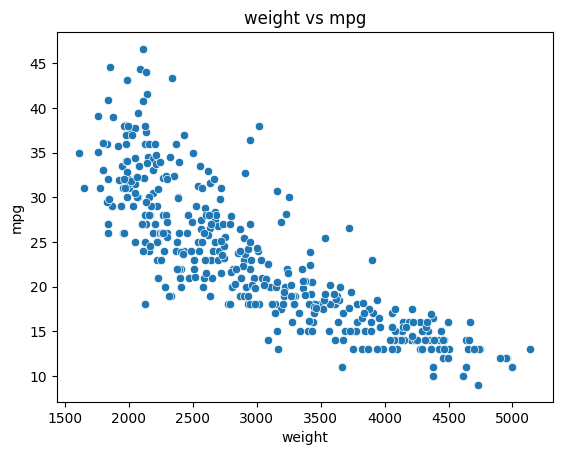

In [9]:

sns.scatterplot(data=df, x='weight', y='mpg')
plt.title('weight vs mpg')
plt.show()

The points fall from top-left to bottom-right. Heavier cars get lower mileage.

The pattern is there. Now we need one line that describes it.

---
## 6. One feature

> **Flow:** `weight` in, `mpg` out.

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train[['weight']], y_train)
print("coef:   ", model.coef_)
print("intercept:", model.intercept_)

coef:    [-0.00780524]
intercept: 46.7820633664505


```
mpg = -0.0078 × weight + 46.78
```

The coefficient is negative — heavier car, lower mileage.
That one number is the entire model.

In [11]:
print(model.score(X_test[['weight']], y_test)) # r2 score 

0.7229710573030748


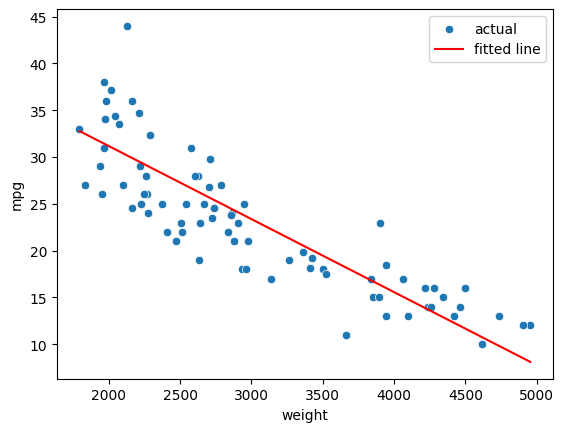

In [12]:
sns.scatterplot(x=X_test['weight'], y=y_test, label='actual')
sns.lineplot(x=X_test['weight'], y=model.predict(X_test[['weight']]),
             color='red', label='fitted line')
plt.show()

---
## 7. All features

> **Flow:** Same model, more columns. No scaling, no encoding.

In [13]:
model_all = LinearRegression()
model_all.fit(X_train, y_train)
print(model_all.score(X_test, y_test))

0.824424533094336


One feature gave 0.723. All six give 0.824.


**A note on scaling.** Last class KNN needed it badly. Linear regression does not — it
measures no distances. Scaling only changes the units the coefficients are written in,
not the predictions.

---
## 8. Metrics

> **Flow:** Accuracy does not work here. The answer is a number, not a label.

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_all.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:  ", r2_score(y_test, y_pred))

MAE:  2.466780800452031
RMSE: 3.0724694408998383
R2:   0.824424533094336


| Metric | Value | Meaning |
|---|---|---|
| MAE | 2.47 | on average, off by 2.47 mpg |
| RMSE | 3.07 | large errors count more |
| R² | 0.824 | 0 = no better than guessing the average, 1 = perfect |

RMSE is always greater than or equal to MAE.

In [16]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.2, random_state=7)
print(LinearRegression().fit(X_tr2, y_tr2).score(X_te2, y_te2))

0.7197593303392956


Same data, same model, different split — different score.
We come back to this in a later class.

### Practice 8

**Q1.** A house price model reports MAE = 2.5 lakh. What does that mean in one line?

**Q2.** Model A has R² = 0.91, model B has R² = 0.40. Which is better, and what does
R² = 0 mean?

<details><summary>Answers</summary>

1. On average the predicted price is off by 2.5 lakh.
2. A. R² = 0 means no better than always guessing the average price.
</details>

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sclaed = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_sclaed.shape,X_test_scaled.shape)

(318, 6) (80, 6)


In [20]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_sclaed, y_train)
print("without scaling:", model_all.score(X_test, y_test))
print("with scaling:   ", model_scaled.score(X_test_scaled, y_test))

without scaling: 0.824424533094336
with scaling:    0.8244245330943358


In [23]:
pd.DataFrame({
    'feature': X_train.columns,
    'coef without scaling': model_all.coef_.round(3),
    'coef with scaling': model_scaled.coef_.round(3)
})

,feature,coef without scaling,coef with scaling
0,cylinders,0.069,0.116
1,displacement,0.002,0.165
2,horsepower,0.003,0.107
3,weight,-0.007,-5.912
4,acceleration,0.081,0.222
5,model_year,0.801,2.883


In [28]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
acc_knn_raw = knn.score(X_test, y_test)
print( acc_knn_raw)


0.7659996807953288


In [27]:
knn_scaled = KNeighborsRegressor()
knn_scaled.fit(X_train_sclaed, y_train)
acc_knn_scaled = knn_scaled.score(X_test_scaled, y_test)
print(acc_knn_scaled)

0.8785489694954951


In [29]:
pd.DataFrame({
    'model': ['Linear Regression',
    'KNN Regressor(no scaling)',
    'KNN Regressor(scaled)'],
    'R2':[round(model_all.score(X_test, y_test), 4),
          round(acc_knn_raw, 4),
          round(acc_knn_scaled, 4)]
})

,model,R2
0,Linear Regression,0.8244
1,KNN Regressor(no scaling),0.7660
2,KNN Regressor(scaled),0.8785
